In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('employee_sla_status.csv')
df

,Employee_ID,Tasks_Assigned,Tasks_Completed,Avg_TAT_Hours,Error_Rate,Quality_Score,Escalations,Rework_Count,Experience_Years,Team,Shift,SLA_Status
0,EMP_6439,104,104,2.27,10.89,83.62,1,6,2.1,Support,Night,Met
1,EMP_8984,108,108,2.54,3.88,79.96,6,13,1.4,Ads,Day,Breached
2,EMP_8559,184,85,4.24,11.60,98.72,3,11,7.9,Ads,Night,Breached
3,EMP_559,119,119,NaN,NaN,NaN,8,12,4.0,Support,Day,Breached
4,EMP_8376,139,139,5.13,8.30,88.55,6,14,7.4,Support,Day,Breached
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP_2467,120,120,3.50,8.78,64.52,9,0,0.9,QA,Night,Breached
9996,EMP_8837,192,105,5.03,8.91,76.35,8,7,2.8,Ads,Day,Breached
9997,EMP_2977,86,86,8.76,12.65,71.27,9,3,6.3,Moderation,Day,Breached
9998,EMP_6881,177,93,6.24,3.43,61.15,0,4,5.9,QA,Day,Breached


In [150]:
df.head()

,Employee_ID,Tasks_Assigned,Tasks_Completed,Avg_TAT_Hours,Error_Rate,Quality_Score,Escalations,Rework_Count,Experience_Years,Team,Shift,SLA_Status
0,EMP_6439,104,104,2.27,10.89,83.62,1,6,2.1,Support,Night,Met
1,EMP_8984,108,108,2.54,3.88,79.96,6,13,1.4,Ads,Day,Breached
2,EMP_8559,184,85,4.24,11.60,98.72,3,11,7.9,Ads,Night,Breached
3,EMP_559,119,119,NaN,NaN,NaN,8,12,4.0,Support,Day,Breached
4,EMP_8376,139,139,5.13,8.30,88.55,6,14,7.4,Support,Day,Breached


In [151]:
df.tail()

,Employee_ID,Tasks_Assigned,Tasks_Completed,Avg_TAT_Hours,Error_Rate,Quality_Score,Escalations,Rework_Count,Experience_Years,Team,Shift,SLA_Status
9995,EMP_2467,120,120,3.50,8.78,64.52,9,0,0.9,QA,Night,Breached
9996,EMP_8837,192,105,5.03,8.91,76.35,8,7,2.8,Ads,Day,Breached
9997,EMP_2977,86,86,8.76,12.65,71.27,9,3,6.3,Moderation,Day,Breached
9998,EMP_6881,177,93,6.24,3.43,61.15,0,4,5.9,QA,Day,Breached
9999,EMP_4452,124,124,5.16,5.97,94.01,3,11,4.5,Support,Day,Met


In [152]:
df.replace("", pd.NA, inplace=True)

In [153]:
df.dtypes

,0
Employee_ID,object
Tasks_Assigned,int64
Tasks_Completed,int64
Avg_TAT_Hours,float64
Error_Rate,float64
Quality_Score,float64
Escalations,int64
Rework_Count,int64
Experience_Years,float64
Team,object


In [154]:
team=df['Team'].value_counts()
team

,count
Team,
Moderation,2592
Support,2540
QA,2454
Ads,2414


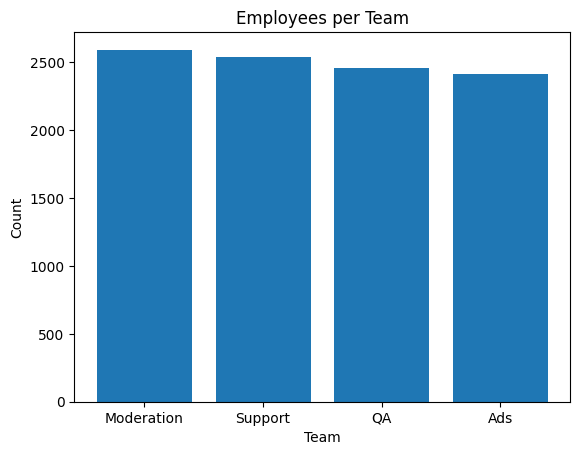

In [155]:
plt.bar(team.index,team.values)
plt.xlabel("Team")
plt.ylabel("Count")
plt.title("Employees per Team")
plt.show()


In [156]:
shift=df['Shift'].value_counts()
shift

,count
Shift,
Day,5057
Night,4943


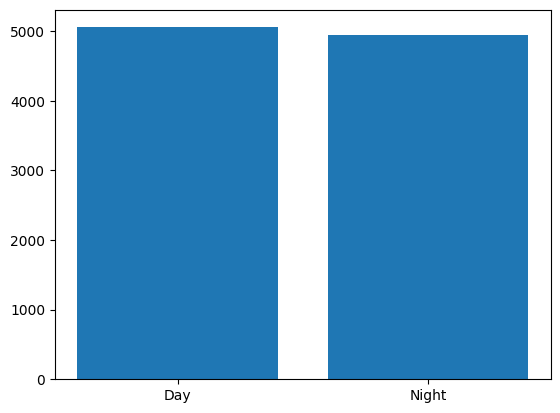

In [157]:
plt.bar(shift.index,shift.values)
plt.show()

In [158]:
sla=df['SLA_Status'].value_counts()
sla

,count
SLA_Status,
Breached,6000
Met,4000


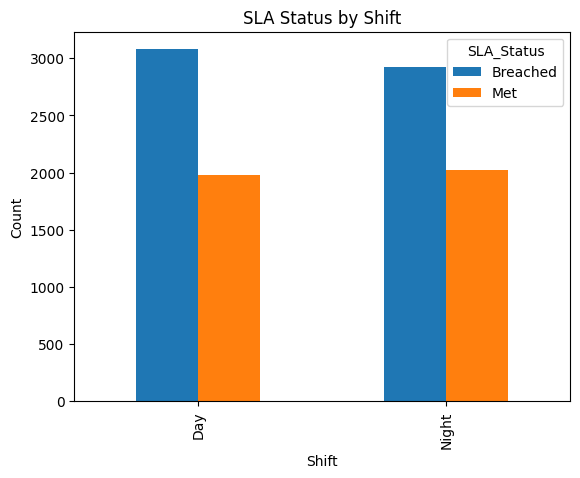

In [159]:
shift_sla = pd.crosstab(df['Shift'], df['SLA_Status'])

shift_sla.plot(kind='bar')
plt.title("SLA Status by Shift")
plt.ylabel("Count")
plt.show()

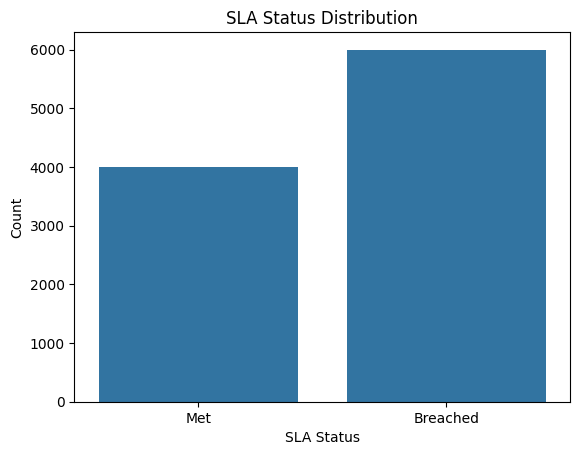

In [160]:
sns.countplot(x='SLA_Status', data=df)

plt.title("SLA Status Distribution")
plt.xlabel("SLA Status")
plt.ylabel("Count")
plt.show()

In [161]:
cor=df.corr(numeric_only=True)
cor

,Tasks_Assigned,Tasks_Completed,Avg_TAT_Hours,Error_Rate,Quality_Score,Escalations,Rework_Count,Experience_Years
Tasks_Assigned,1.000000,0.564714,0.027287,0.014075,-0.007935,0.035655,0.013252,-0.017781
Tasks_Completed,0.564714,1.000000,-0.006364,-0.030156,0.037886,0.008329,-0.040300,-0.009579
Avg_TAT_Hours,0.027287,-0.006364,1.000000,0.027266,-0.065401,0.030237,0.039194,0.016854
Error_Rate,0.014075,-0.030156,0.027266,1.000000,-0.041569,-0.022433,-0.039413,0.000934
Quality_Score,-0.007935,0.037886,-0.065401,-0.041569,1.000000,-0.020298,-0.043085,-0.008067
Escalations,0.035655,0.008329,0.030237,-0.022433,-0.020298,1.000000,-0.016772,0.011820
Rework_Count,0.013252,-0.040300,0.039194,-0.039413,-0.043085,-0.016772,1.000000,-0.030359
Experience_Years,-0.017781,-0.009579,0.016854,0.000934,-0.008067,0.011820,-0.030359,1.000000


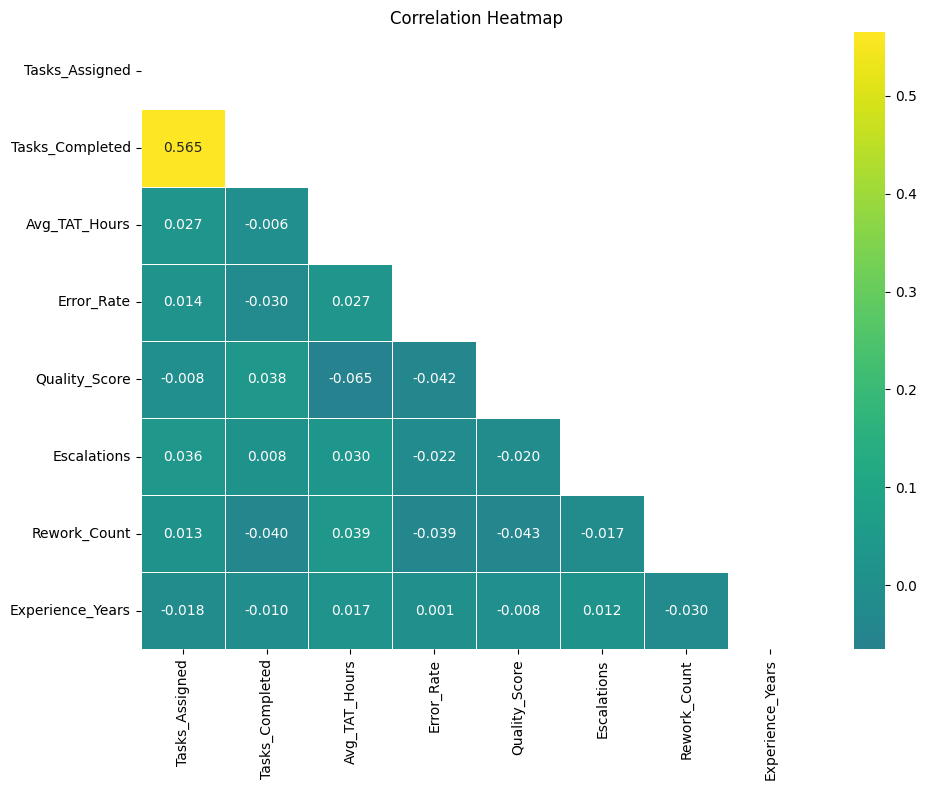

In [162]:
plt.figure(figsize=(10,8))
mask = np.triu(cor)
sns.heatmap(
    cor,
    mask=mask,
    annot=True,
    cmap='viridis',
    center=0,
    fmt='.3f',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

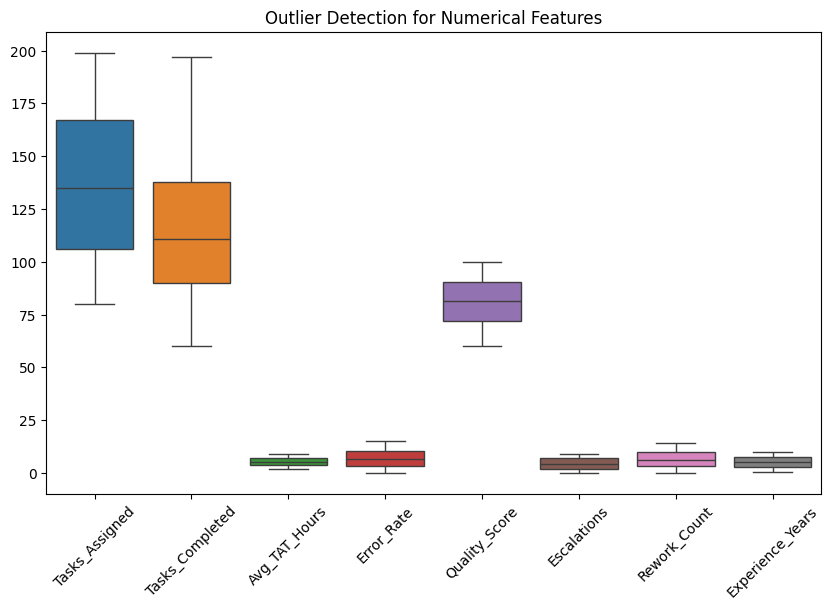

In [163]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=45)
plt.title("Outlier Detection for Numerical Features")
plt.show()

In [164]:
df.isna().sum()

,0
Employee_ID,0
Tasks_Assigned,0
Tasks_Completed,0
Avg_TAT_Hours,1099
Error_Rate,1099
Quality_Score,1099
Escalations,0
Rework_Count,0
Experience_Years,0
Team,0


In [165]:
df_encoding=pd.get_dummies(df[['Team','Shift']],drop_first=True,dtype=int)
df_encoding

,Team_Moderation,Team_QA,Team_Support,Shift_Night
0,0,0,1,1
1,0,0,0,0
2,0,0,0,1
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
9995,0,1,0,1
9996,0,0,0,0
9997,1,0,0,0
9998,0,1,0,0


In [166]:
df['SLA_Status'].unique()

array(['Met', 'Breached'], dtype=object)

In [167]:
df['SLA_Status'] = df['SLA_Status'].map({'Breached':0, 'Met':1})

In [168]:
df

,Employee_ID,Tasks_Assigned,Tasks_Completed,Avg_TAT_Hours,Error_Rate,Quality_Score,Escalations,Rework_Count,Experience_Years,Team,Shift,SLA_Status
0,EMP_6439,104,104,2.27,10.89,83.62,1,6,2.1,Support,Night,1
1,EMP_8984,108,108,2.54,3.88,79.96,6,13,1.4,Ads,Day,0
2,EMP_8559,184,85,4.24,11.60,98.72,3,11,7.9,Ads,Night,0
3,EMP_559,119,119,NaN,NaN,NaN,8,12,4.0,Support,Day,0
4,EMP_8376,139,139,5.13,8.30,88.55,6,14,7.4,Support,Day,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP_2467,120,120,3.50,8.78,64.52,9,0,0.9,QA,Night,0
9996,EMP_8837,192,105,5.03,8.91,76.35,8,7,2.8,Ads,Day,0
9997,EMP_2977,86,86,8.76,12.65,71.27,9,3,6.3,Moderation,Day,0
9998,EMP_6881,177,93,6.24,3.43,61.15,0,4,5.9,QA,Day,0


In [169]:
dfe=pd.concat([df,df_encoding],axis=1)
dfe

,Employee_ID,Tasks_Assigned,Tasks_Completed,Avg_TAT_Hours,Error_Rate,Quality_Score,Escalations,Rework_Count,Experience_Years,Team,Shift,SLA_Status,Team_Moderation,Team_QA,Team_Support,Shift_Night
0,EMP_6439,104,104,2.27,10.89,83.62,1,6,2.1,Support,Night,1,0,0,1,1
1,EMP_8984,108,108,2.54,3.88,79.96,6,13,1.4,Ads,Day,0,0,0,0,0
2,EMP_8559,184,85,4.24,11.60,98.72,3,11,7.9,Ads,Night,0,0,0,0,1
3,EMP_559,119,119,NaN,NaN,NaN,8,12,4.0,Support,Day,0,0,0,1,0
4,EMP_8376,139,139,5.13,8.30,88.55,6,14,7.4,Support,Day,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP_2467,120,120,3.50,8.78,64.52,9,0,0.9,QA,Night,0,0,1,0,1
9996,EMP_8837,192,105,5.03,8.91,76.35,8,7,2.8,Ads,Day,0,0,0,0,0
9997,EMP_2977,86,86,8.76,12.65,71.27,9,3,6.3,Moderation,Day,0,1,0,0,0
9998,EMP_6881,177,93,6.24,3.43,61.15,0,4,5.9,QA,Day,0,0,1,0,0


In [170]:
dfe.drop(['Employee_ID','Team','Shift'],axis=1,inplace=True)
dfe

,Tasks_Assigned,Tasks_Completed,Avg_TAT_Hours,Error_Rate,Quality_Score,Escalations,Rework_Count,Experience_Years,SLA_Status,Team_Moderation,Team_QA,Team_Support,Shift_Night
0,104,104,2.27,10.89,83.62,1,6,2.1,1,0,0,1,1
1,108,108,2.54,3.88,79.96,6,13,1.4,0,0,0,0,0
2,184,85,4.24,11.60,98.72,3,11,7.9,0,0,0,0,1
3,119,119,NaN,NaN,NaN,8,12,4.0,0,0,0,1,0
4,139,139,5.13,8.30,88.55,6,14,7.4,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,120,120,3.50,8.78,64.52,9,0,0.9,0,0,1,0,1
9996,192,105,5.03,8.91,76.35,8,7,2.8,0,0,0,0,0
9997,86,86,8.76,12.65,71.27,9,3,6.3,0,1,0,0,0
9998,177,93,6.24,3.43,61.15,0,4,5.9,0,0,1,0,0


In [171]:
dfe.dtypes

,0
Tasks_Assigned,int64
Tasks_Completed,int64
Avg_TAT_Hours,float64
Error_Rate,float64
Quality_Score,float64
Escalations,int64
Rework_Count,int64
Experience_Years,float64
SLA_Status,int64
Team_Moderation,int64


In [172]:
dfe.isna().sum()

,0
Tasks_Assigned,0
Tasks_Completed,0
Avg_TAT_Hours,1099
Error_Rate,1099
Quality_Score,1099
Escalations,0
Rework_Count,0
Experience_Years,0
SLA_Status,0
Team_Moderation,0


In [173]:
dfe['Avg_TAT_Hours'].unique()

array([2.27, 2.54, 4.24,  nan, 5.13, 4.02, 8.81, 5.71, 4.74, 4.3 , 2.25,
       5.43, 3.32, 2.99, 6.89, 4.77, 6.  , 4.7 , 5.73, 3.55, 4.59, 8.03,
       4.88, 8.94, 6.79, 4.27, 2.41, 6.63, 7.71, 4.57, 6.8 , 3.64, 5.52,
       8.86, 6.96, 5.49, 6.02, 7.23, 6.14, 8.49, 6.1 , 7.52, 7.02, 4.39,
       7.97, 5.6 , 4.37, 7.25, 2.33, 3.31, 3.96, 5.82, 7.1 , 8.48, 2.5 ,
       3.06, 2.12, 3.05, 5.36, 5.19, 7.53, 3.73, 3.01, 8.09, 4.73, 7.82,
       2.  , 2.45, 5.02, 4.89, 5.53, 3.61, 4.36, 5.47, 5.25, 8.62, 5.45,
       6.26, 2.31, 7.9 , 4.79, 6.38, 3.45, 2.76, 4.92, 3.09, 6.68, 6.56,
       8.63, 5.22, 3.21, 7.22, 4.87, 6.37, 7.56, 3.58, 5.5 , 6.25, 3.53,
       7.8 , 8.18, 8.71, 5.05, 5.26, 8.17, 8.22, 3.03, 7.13, 3.35, 4.51,
       8.45, 7.5 , 8.39, 4.09, 2.38, 8.8 , 2.82, 8.65, 4.78, 5.28, 7.98,
       4.17, 5.79, 2.22, 6.18, 5.56, 7.79, 7.11, 8.47, 4.84, 5.65, 8.27,
       7.59, 5.11, 3.57, 8.53, 6.17, 4.44, 6.98, 4.96, 3.27, 3.89, 8.13,
       5.74, 6.01, 6.31, 2.92, 6.29, 3.71, 5.64, 4.

In [174]:
dfe['Error_Rate'].unique()

array([10.89,  3.88, 11.6 , ..., 11.58, 10.92,  8.51])

In [175]:
dfe['Quality_Score'].unique()

array([83.62, 79.96, 98.72, ..., 81.53, 60.76, 64.27])

In [176]:
dfe['Avg_TAT_Hours']=dfe['Avg_TAT_Hours'].fillna(df['Avg_TAT_Hours'].mean())
dfe['Error_Rate']=dfe['Error_Rate'].fillna(df['Error_Rate'].median())
dfe['Quality_Score']=dfe['Quality_Score'].fillna(df['Quality_Score'].median())


In [177]:
dfe.isna().sum()

,0
Tasks_Assigned,0
Tasks_Completed,0
Avg_TAT_Hours,0
Error_Rate,0
Quality_Score,0
Escalations,0
Rework_Count,0
Experience_Years,0
SLA_Status,0
Team_Moderation,0


In [178]:
x = dfe.drop('SLA_Status', axis=1)
y = dfe['SLA_Status']

In [179]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [180]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [181]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42)

# model.fit(x_train, y_train)

KNeighborsClassifier()

In [183]:
y_pred = model.predict(x_test)

In [184]:
# from sklearn.metrics import accuracy_score, classification_report

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [185]:
from sklearn.metrics import accuracy_score
ac=accuracy_score(y_test,y_pred)
ac

0.831

In [186]:
from sklearn.model_selection import GridSearchCV
model1=KNeighborsClassifier()
data={'n_neighbors':[3,5,7,9,11],'weights':['uniform','distance']}
clf=GridSearchCV(model1,data,cv=10,scoring='accuracy')
clf.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [187]:
print(clf.best_params_)

{'n_neighbors': 9, 'weights': 'distance'}


In [188]:
model2=KNeighborsClassifier(n_neighbors=9,weights='distance')
model2.fit(x_train,y_train)
y_pred1=model2.predict(x_train)
y_pred1

array([0, 0, 0, ..., 1, 1, 0])

In [189]:
y_pred1=model2.predict(x_test)
score1=accuracy_score(y_test,y_pred1)
score1

0.9005